In [8]:
from pathlib import Path
import sys
import numpy as np

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.preprocessing.image_preprocessing import preprocess_image

In [2]:
DATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "IDRiD"
    / "B. Disease Grading"
)

TRAIN_IMAGE_DIR = (
    DATA_DIR
    / "1. Original Images"
    / "a. Training Set"
)

image_path = sorted(TRAIN_IMAGE_DIR.glob("*.jpg"))[0]

result = preprocess_image(image_path)

In [3]:
result = preprocess_image(image_path)

masked_rgb = result["masked_rgb"]
retinal_mask = result["retinal_mask"]
green_channel = result["green_channel"]
green_enhanced = result["green_enhanced"]

In [4]:
print(masked_rgb.shape)
print(retinal_mask.shape)
print(green_channel.shape)
print(green_enhanced.shape)

(512, 512, 3)
(512, 512)
(512, 512)
(512, 512)


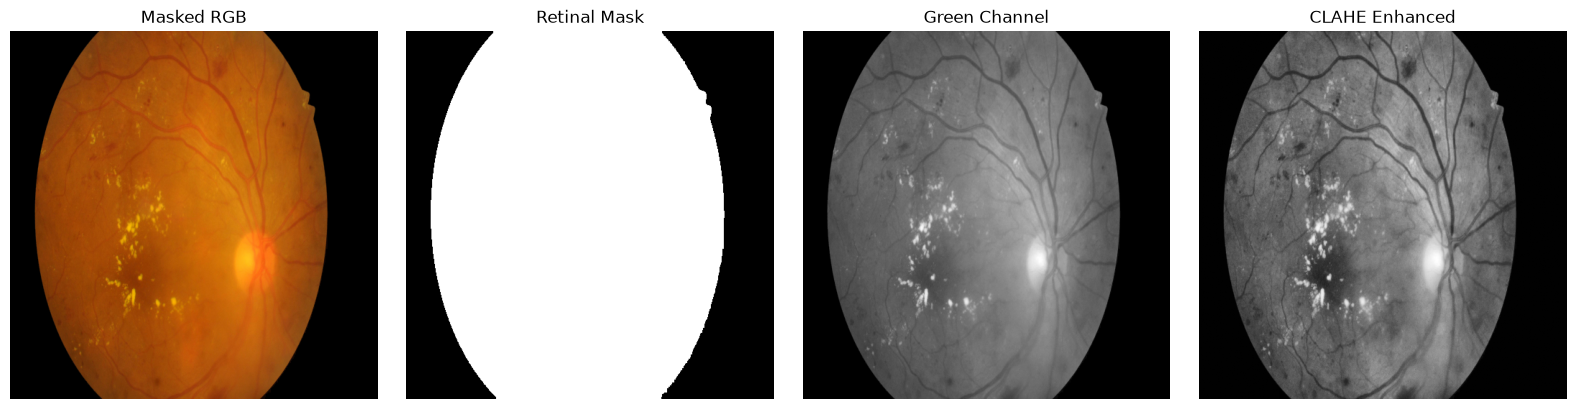

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.imshow(masked_rgb)
plt.title("Masked RGB")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(retinal_mask, cmap="gray")
plt.title("Retinal Mask")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(green_channel, cmap="gray")
plt.title("Green Channel")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(green_enhanced, cmap="gray")
plt.title("CLAHE Enhanced")
plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
pixels = masked_rgb[retinal_mask > 0]

print(pixels.shape)

(181801, 3)


In [9]:
color_features = {
    "mean_r": np.mean(pixels[:, 0]),
    "mean_g": np.mean(pixels[:, 1]),
    "mean_b": np.mean(pixels[:, 2]),

    "std_r": np.std(pixels[:, 0]),
    "std_g": np.std(pixels[:, 1]),
    "std_b": np.std(pixels[:, 2]),

    "median_r": np.median(pixels[:, 0]),
    "median_g": np.median(pixels[:, 1]),
    "median_b": np.median(pixels[:, 2]),
}

color_features

{'mean_r': np.float64(171.87454414442163),
 'mean_g': np.float64(84.76140945319332),
 'mean_b': np.float64(10.862817036209922),
 'std_r': np.float64(28.550962815591618),
 'std_g': np.float64(20.078228438092736),
 'std_b': np.float64(4.606146608640323),
 'median_r': np.float64(170.0),
 'median_g': np.float64(82.0),
 'median_b': np.float64(10.0)}